<a href="https://colab.research.google.com/github/georgevallejo/LG_Python_Projects/blob/main/First_Assignment_311_service_Request_analysis_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 8/24/2026 LaGuardia Python / First Assignment

1) import pandas and load May 2019 dataset to collab

In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')

/tmp/ipykernel_11611/2471651318.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')


In [2]:
# Question 1 # of rows and columns
df.shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()

# df.info() # Similar information rangeIndex (rows) and Data columns.  Rather use this function for now
# df.columns  # column header details
# df.head(5)  # viewing the 5 first rows in the dataset
df.info()
# rather use df.info() it provides addtional information about the dataset and also shows the
# rows = 69637 Columns = 21

Rows: 69637
Columns: 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69637 entries, 0 to 69636
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unique Key              69637 non-null  int64  
 1   Created Date            69637 non-null  object 
 2   Closed Date             64626 non-null  object 
 3   Agency                  69637 non-null  object 
 4   Complaint Type          69637 non-null  object 
 5   Location Type           53978 non-null  object 
 6   Incident Zip            67389 non-null  object 
 7   Incident Address        59033 non-null  object 
 8   Street Name             59032 non-null  object 
 9   Address Type            68307 non-null  object 
 10  City                    67416 non-null  object 
 11  Landmark                16 non-null     object 
 12  Facility Type           24081 non-null  object 
 13  Status                  69637 non-null  object 
 14  Due Date     

In [3]:
# Question #2
# showing the min and max dates in this dataset df.   The 'Create Date' DType is object / string.
# This as per the documentation is not good when using it for math data calculations
# conversion function dates = pd.to_datetime(dates)

print(
    f"Time Range: "
    f"{df['Created Date'].min()} to "
    f"{df['Created Date'].max()}"
)

# df.info()  # sanity check
# df['Created Date'].max()
# df['Created Date'].min()

# Note: the min and max works because the dataset data is for only May 2019.

Time Range: 5/1/2019 0:00 to 5/9/2019 9:59


In [4]:
# Question 3.  Statistics.
print(df.columns) # used to have a better view of all the columns in this dataset
df.describe()     # This function was suggested to be used during our class
# there is no value on the output of describe at this point.
# There are numeric values that will not provide any valueble information for Statistical Analysis. ie: Unique Key.

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Address Type', 'City', 'Landmark', 'Facility Type', 'Status',
       'Due Date', 'Resolution Description', 'BBL', 'Borough', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')


,Unique Key,BBL,Latitude,Longitude
count,6.963700e+04,5.570200e+04,65634.000000,65634.000000
mean,4.260307e+07,2.869652e+09,40.723149,-73.924517
std,5.269818e+04,1.184250e+09,0.083621,0.085089
min,4.251278e+07,0.000000e+00,40.500025,-74.252279
25%,4.258004e+07,2.030690e+09,40.664461,-73.972161
50%,4.260019e+07,3.034830e+09,40.716443,-73.929758
75%,4.262095e+07,4.023330e+09,40.780783,-73.874064
max,4.297343e+07,5.080480e+09,40.912869,-73.700597


<Axes: title={'center': 'Visualization 1: Complaints by Borough'}, xlabel='Borough'>

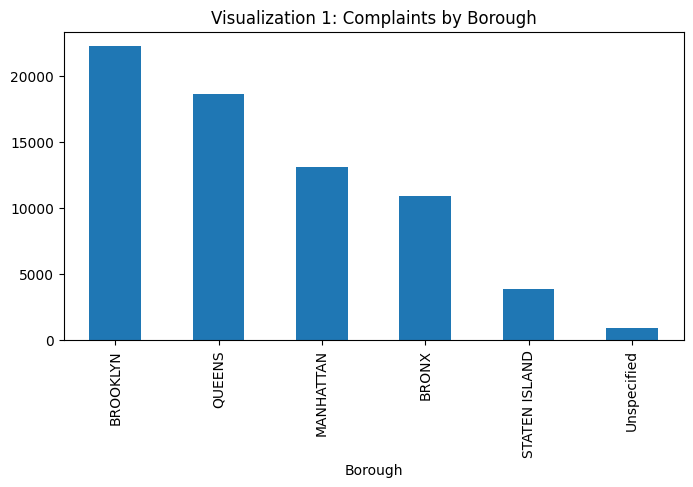

In [5]:
# Question #4 Visualizations
# Visualization #1 Borough.  Including Unspecified.
# This Unspecified value should be evaluated later to either fix it or just drop it all together.
df['Borough'].value_counts().plot(
    kind='bar',
    figsize=(8,4),
    title='Visualization 1: Complaints by Borough'
)

<Axes: title={'center': 'Visualization 2: Complaints by Agency'}, xlabel='Agency'>

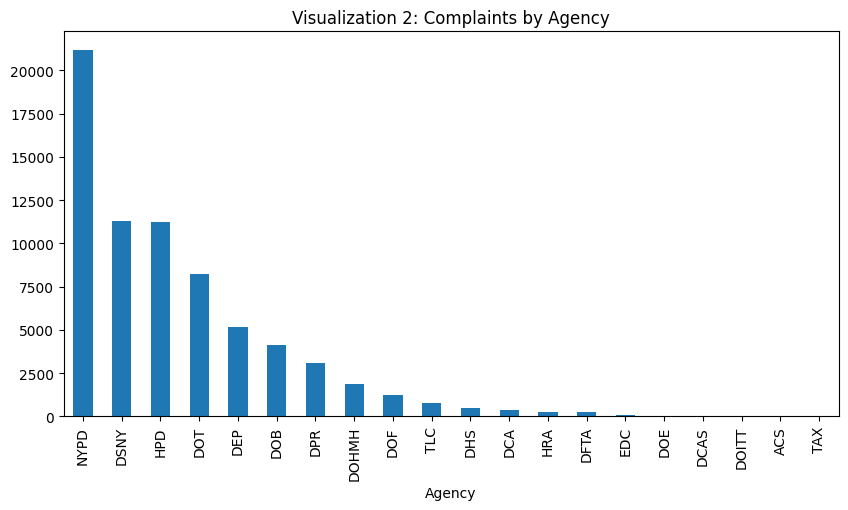

In [6]:
# Creating complain type chart using type bar for Agency type
df['Agency'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Visualization 2: Complaints by Agency'
)


<Axes: title={'center': 'Visualization 3:  Complaint Type'}>

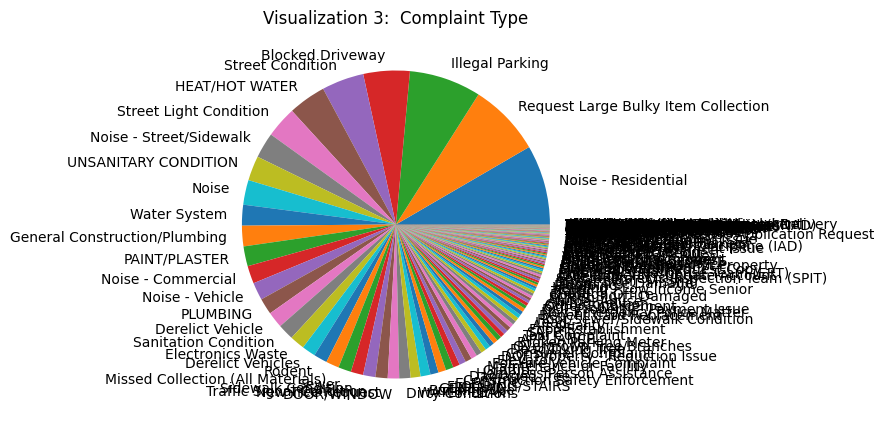

In [7]:
# Creating a pie chart about all the complain types
df['Complaint Type'].value_counts().plot(
    kind='pie',
    figsize=(10, 5),
    title='Visualization 3:  Complaint Type',
 #    autopct='%1.1f%%',  kind =
    ylabel=''

)
# This pie chart is too busy.  I will create a differnt version.

<Axes: title={'center': 'Visualization 2: Top 15 Complaint Types + Sum everything else as Other'}>

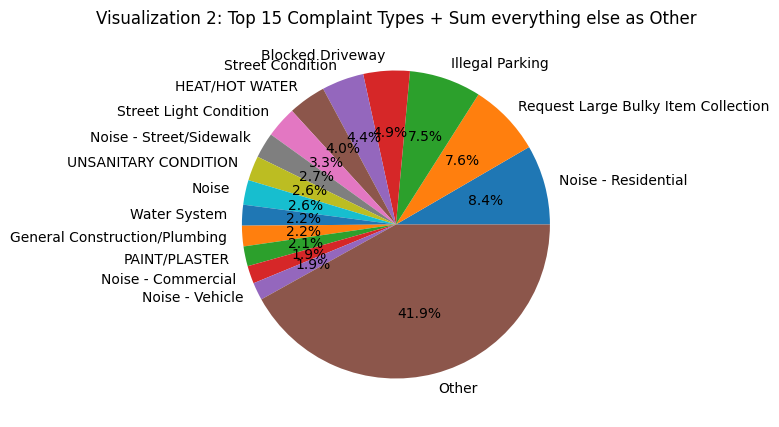

In [8]:
# Getting the 15 top "Complaint types", and agregating all other type of complains as remaining_complaints
# 1-Count complaint types. 2-Keep the top 15. 3-Sum everything else.
# 4-Add a row called "Other" containing that sum. 5-Plot the pie chart.

# Count complaints by type
counts = df['Complaint Type'].value_counts() # First Series

# Keep only the top 15 complaint types
top15 = counts.head(15).copy()               # Second Series

# Sum all remaining complaint types
remaining_complaints = counts.iloc[15:].sum()   # Thrid Series

# Add "Other" to the Series.  Adds an additional row to the Series
top15.loc['Other'] = remaining_complaints

# Create the pie chart
top15.plot(
    kind='pie',
    figsize=(10, 5),
    title='Visualization 2: Top 15 Complaint Types + Sum everything else as Other',
    autopct='%1.1f%%',
    ylabel=''
)


In [9]:
# @title Sanity Check.  Verifying type of object and variable values
# Verify the objects and values  Sanity Check
print(type(counts))
print(type(top15))
print()

print("Value assigned to Other:")
print(remaining_complaints)
print()

print("Top 15 + Other:")
print(top15)

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>

Value assigned to Other:
29191

Top 15 + Other:
Complaint Type
Noise - Residential                     5838
Request Large Bulky Item Collection     5301
Illegal Parking                         5257
Blocked Driveway                        3391
Street Condition                        3080
HEAT/HOT WATER                          2755
Street Light Condition                  2283
Noise - Street/Sidewalk                 1866
UNSANITARY CONDITION                    1809
Noise                                   1805
Water System                            1519
General Construction/Plumbing           1503
PAINT/PLASTER                           1452
Noise - Commercial                      1297
Noise - Vehicle                         1290
Other                                  29191
Name: count, dtype: int64


In [10]:
# Question #5 what borough has the most complaints
df['Borough'].value_counts()
df['Borough'].value_counts().head(1)
# Brooklyn has the most complains with 22247 service requests.

,count
Borough,
BROOKLYN,22247


<Axes: title={'center': 'Noise Complaints by Borough'}, xlabel='Borough'>

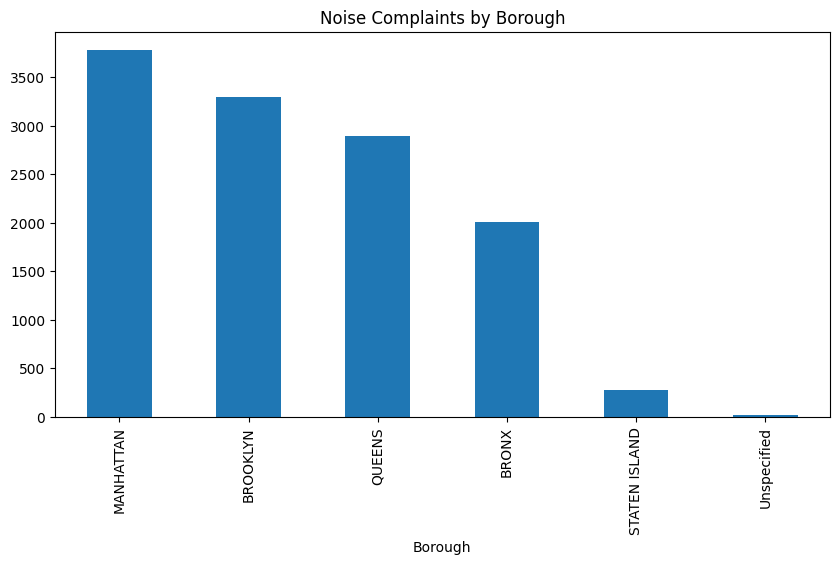

In [11]:
# Question #6  Noise complains by Borough
# "Ignore upper/lower case differences." case = False
# "Treat missing values as False." na = False
noise_counts = (
    df[df['Complaint Type'].str.contains('noise', case=False, na=False)]
      .groupby('Borough')
      .size()
      .sort_values(ascending=False)
)

noise_counts.plot(
    kind='bar',
    figsize=(10,5),
    title='Noise Complaints by Borough'
)


In [12]:
# question 6 find one more interesting piece of information (anything)
total_records = len(df)
print(f"Total records: {total_records:,}")
# (df.count() / len(df) * 100).sort_values() # used round for this expression to make it more readable
round((df.count() / len(df) * 100), 2).sort_values()
# Landmark: 99.98% of the values are missing

Total records: 69,637


,0
Landmark,0.02
Facility Type,34.58
Due Date,47.16
Location Type,77.51
BBL,79.99
Street Name,84.77
Incident Address,84.77
Resolution Description,91.30
Closed Date,92.80
Location,94.25


In [13]:
# Question # 6 revision with a friendlier output.
data_quality = pd.DataFrame({
    'NonNullCount': df.count(),
    'Completeness%': round(df.count() / len(df) * 100, 2)
})

data_quality.sort_values(
    by='Completeness%',
    ascending=True
)

,NonNullCount,Completeness%
Landmark,16,0.02
Facility Type,24081,34.58
Due Date,32839,47.16
Location Type,53978,77.51
BBL,55702,79.99
Street Name,59032,84.77
Incident Address,59033,84.77
Resolution Description,63579,91.30
Closed Date,64626,92.80
Location,65634,94.25
